# Sistemas de Recomendação: 8 Abordagens

Comparação de **8 paradigmas** de recomendação no MovieLens 100k:
- **Popularidade** — baseline heurística
- **KNN User-based / Item-based** — similaridade
- **SVD** — Matrix Factorization canônica
- **NCF** — Neural Collaborative Filtering
- **LightGBM + Feature Engineering** — regressão tabular
- **BPR** — Matrix Factorization com loss pairwise (ranking)
- **Two-Tower (DLRM-style)** — torres separadas + produto escalar

In [1]:
import os, sys, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import lightgbm as lgb

from surprise import Dataset, KNNBasic, SVD, accuracy
from surprise.model_selection import train_test_split as surprise_split

warnings.filterwarnings('ignore')
sns.set_theme(style='darkgrid')

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

Device: cuda


## 1. Dataset: MovieLens 100k

Shape: (100000, 4)
Usuarios: 943, Itens: 1682
Sparsity: 0.9370
count    100000.000000
mean          3.529860
std           1.125674
min           1.000000
25%           3.000000
50%           4.000000
75%           4.000000
max           5.000000
Name: rating, dtype: float64


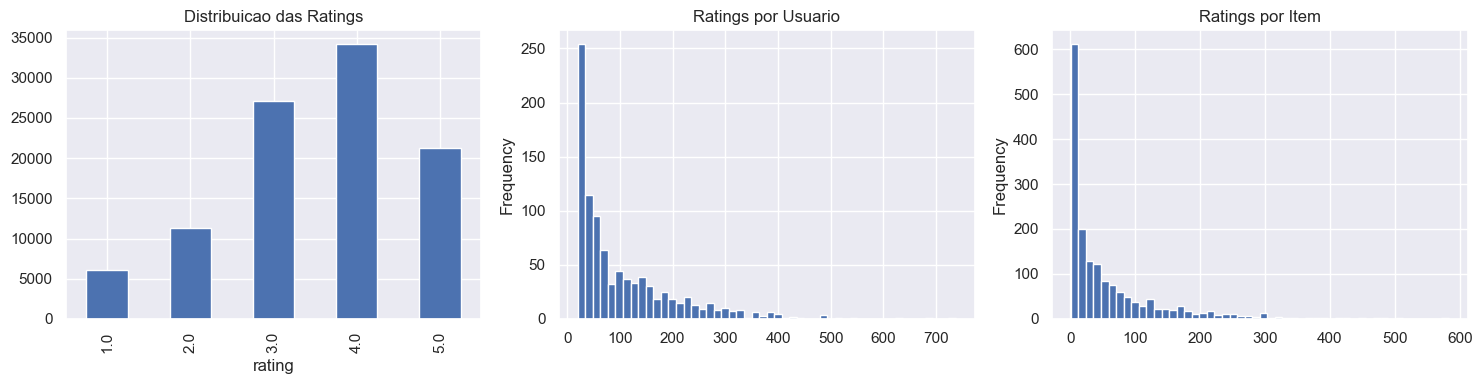

In [2]:
data = Dataset.load_builtin('ml-100k')
raw = pd.DataFrame(data.raw_ratings, columns=['user', 'item', 'rating', 'timestamp'])
raw['user'] = raw['user'].astype(int)
raw['item'] = raw['item'].astype(int)
print(f'Shape: {raw.shape}')
print(f'Usuarios: {raw["user"].nunique()}, Itens: {raw["item"].nunique()}')
print(f'Sparsity: {1 - len(raw) / (raw["user"].nunique() * raw["item"].nunique()):.4f}')
print(raw['rating'].describe())

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
raw['rating'].value_counts().sort_index().plot(kind='bar', ax=axes[0], title='Distribuicao das Ratings')
raw.groupby('user').size().plot(kind='hist', bins=50, ax=axes[1], title='Ratings por Usuario')
raw.groupby('item').size().plot(kind='hist', bins=50, ax=axes[2], title='Ratings por Item')
plt.tight_layout(); plt.show()

## 2. Preparação

Split 80/20 para modelos surprise, LightGBM e NCF/Towers.

In [3]:
trainset, testset = surprise_split(data, test_size=0.2, random_state=SEED)
train_raw, test_raw = train_test_split(raw, test_size=0.2, random_state=SEED)

all_users = sorted(raw['user'].unique())
all_items = sorted(raw['item'].unique())
u2i = {u: i for i, u in enumerate(all_users)}
i2i = {m: i for i, m in enumerate(all_items)}
N_USERS, N_ITEMS = len(all_users), len(all_items)
print(f'Treino: {len(train_raw)}, Teste: {len(test_raw)}, N_USERS={N_USERS}, N_ITEMS={N_ITEMS}')

Treino: 80000, Teste: 20000, N_USERS=943, N_ITEMS=1682


## 3. Baseline: Popularidade

In [4]:
pop = train_raw.groupby('item').agg({'rating': ['mean', 'count']}).droplevel(0, axis=1)
pop.columns = ['mean_rating', 'count']
pop = pop[pop['count'] >= 5].sort_values('mean_rating', ascending=False)

def pop_predict(_item):
    return pop.loc[_item, 'mean_rating'] if _item in pop.index else 3.0

pop_preds = [pop_predict(i) for i in test_raw['item']]
pop_rmse = np.sqrt(mean_squared_error(test_raw['rating'], pop_preds))
print(f'Popularity RMSE: {pop_rmse:.4f}')

Popularity RMSE: 1.0171


## 4. KNN User-based

In [5]:
knn_u = KNNBasic(sim_options={'name': 'cosine', 'user_based': True}, verbose=False)
knn_u.fit(trainset)
knn_u_rmse = accuracy.rmse(knn_u.test(testset), verbose=False)
print(f'KNN User-based RMSE: {knn_u_rmse:.4f}')

KNN User-based RMSE: 1.0194


## 5. KNN Item-based

In [6]:
knn_i = KNNBasic(sim_options={'name': 'cosine', 'user_based': False}, verbose=False)
knn_i.fit(trainset)
knn_i_rmse = accuracy.rmse(knn_i.test(testset), verbose=False)
print(f'KNN Item-based RMSE: {knn_i_rmse:.4f}')

KNN Item-based RMSE: 1.0264


## 6. SVD (Matrix Factorization)

In [7]:
svd = SVD(n_factors=100, n_epochs=20, lr_all=0.005, reg_all=0.02, random_state=SEED, verbose=False)
svd.fit(trainset)
svd_rmse = accuracy.rmse(svd.test(testset), verbose=False)
print(f'SVD RMSE: {svd_rmse:.4f}')

SVD RMSE: 0.9352


## 7. NCF (Neural Collaborative Filtering)

In [8]:
class NCFDataset(Dataset):
    def __init__(self, df, u2i, i2i):
        self.users = torch.tensor(df['user'].map(u2i).values, dtype=torch.long)
        self.items = torch.tensor(df['item'].map(i2i).values, dtype=torch.long)
        self.ratings = torch.tensor(df['rating'].values, dtype=torch.float32)
    def __len__(self): return len(self.ratings)
    def __getitem__(self, idx):
        return self.users[idx], self.items[idx], self.ratings[idx]

class NeuMF(nn.Module):
    def __init__(self, n_users, n_items, embed_dim=32, hidden=[64, 32, 16]):
        super().__init__()
        self.user_emb = nn.Embedding(n_users, embed_dim)
        self.item_emb = nn.Embedding(n_items, embed_dim)
        layers = []
        in_dim = embed_dim * 2
        for h in hidden:
            layers.extend([nn.Linear(in_dim, h), nn.ReLU(), nn.Dropout(0.2)])
            in_dim = h
        layers.append(nn.Linear(in_dim, 1))
        self.mlp = nn.Sequential(*layers)
    def forward(self, users, items):
        u = self.user_emb(users)
        i = self.item_emb(items)
        return self.mlp(torch.cat([u, i], dim=1)).squeeze()

ncf_train = NCFDataset(train_raw, u2i, i2i)
ncf_test = NCFDataset(test_raw, u2i, i2i)
ncf_loader = DataLoader(ncf_train, batch_size=256, shuffle=True)

ncf_model = NeuMF(N_USERS, N_ITEMS, embed_dim=32).to(DEVICE)
ncf_opt = optim.Adam(ncf_model.parameters(), lr=1e-3)
ncf_crit = nn.MSELoss()

for ep in range(20):
    ncf_model.train(); loss_ep = 0.0
    for u, i, r in ncf_loader:
        u, i, r = u.to(DEVICE), i.to(DEVICE), r.to(DEVICE)
        ncf_opt.zero_grad()
        loss = ncf_crit(ncf_model(u, i), r)
        loss.backward(); ncf_opt.step()
        loss_ep += loss.item() * u.size(0)
    if (ep+1) % 5 == 0:
        print(f'NCF ep {ep+1} | loss={loss_ep/len(ncf_train):.4f}')

ncf_model.eval()
with torch.no_grad():
    ncf_preds = ncf_model(ncf_test.users.to(DEVICE), ncf_test.items.to(DEVICE)).cpu().numpy()
ncf_rmse = np.sqrt(mean_squared_error(test_raw['rating'], ncf_preds))
print(f'NCF RMSE: {ncf_rmse:.4f}')

NCF ep 5 | loss=1.4320


NCF ep 10 | loss=1.1745


NCF ep 15 | loss=1.0084


NCF ep 20 | loss=0.9038
NCF RMSE: 0.9462


## 8. LightGBM + Feature Engineering

Cria features tabulares para cada par (usuário, item): estatísticas do usuário, do item, e interação entre eles. Depois treina um Gradient Boosting como regressor.

In [9]:
def build_features(df, global_stats=None):
    feats = df[['user', 'item']].copy()
    aggs = {}
    if global_stats:
        uro, irc = global_stats
    else:
        uro = df.groupby('user')['rating'].agg(['mean', 'std', 'count']).fillna(0).rename(
            columns={'mean': 'u_mean', 'std': 'u_std', 'count': 'u_cnt'})
        irc = df.groupby('item')['rating'].agg(['mean', 'std', 'count']).fillna(0).rename(
            columns={'mean': 'i_mean', 'std': 'i_std', 'count': 'i_cnt'})
        aggs = {'uro': uro, 'irc': irc}
    feats = feats.merge(uro, left_on='user', right_index=True, how='left')
    feats = feats.merge(irc, left_on='item', right_index=True, how='left')
    feats['u_i_cnt'] = feats['u_cnt'] * feats['i_cnt']
    feats['u_i_mean_diff'] = feats['u_mean'] - feats['i_mean']
    return feats.fillna(0), aggs

X_tr, aggs = build_features(train_raw)
X_te, _ = build_features(test_raw, (aggs['uro'], aggs['irc']))
y_tr, y_te = train_raw['rating'], test_raw['rating']
feat_cols = ['u_mean', 'u_std', 'u_cnt', 'i_mean', 'i_std', 'i_cnt', 'u_i_cnt', 'u_i_mean_diff']
print(f'Features: {feat_cols}')

lgb_model = lgb.LGBMRegressor(objective='regression', n_estimators=500, max_depth=8,
                              learning_rate=0.05, random_state=SEED, verbose=-1)
lgb_model.fit(X_tr[feat_cols], y_tr, eval_set=[(X_te[feat_cols], y_te)], callbacks=[lgb.callback.record_evaluation({})])
lgb_preds = lgb_model.predict(X_te[feat_cols])
lgb_rmse = np.sqrt(mean_squared_error(y_te, lgb_preds))
print(f'LightGBM RMSE: {lgb_rmse:.4f}')

imps = pd.DataFrame({'feature': feat_cols, 'importance': lgb_model.feature_importances_}).sort_values('importance', ascending=False)
print('\nFeature Importances:')
print(imps.to_string(index=False))

Features: ['u_mean', 'u_std', 'u_cnt', 'i_mean', 'i_std', 'i_cnt', 'u_i_cnt', 'u_i_mean_diff']


LightGBM RMSE: 0.9406

Feature Importances:
      feature  importance
        u_std        2215
       u_mean        2208
        i_std        2064
      u_i_cnt        1941
       i_mean        1917
        u_cnt        1626
u_i_mean_diff        1571
        i_cnt        1458


## 9. BPR (Bayesian Personalized Ranking)

Matrix Factorization com **loss pairwise**: para cada par positivo (user, item), amostra um item negativo que o usuário não interagiu e otimiza para que a diferença predita (pos - neg) seja positiva. Otimiza **ranking**, não rating absoluto.

In [10]:
class BPRModel(nn.Module):
    def __init__(self, n_users, n_items, n_factors=64):
        super().__init__()
        self.user_factors = nn.Embedding(n_users, n_factors)
        self.item_factors = nn.Embedding(n_items, n_factors)
        nn.init.normal_(self.user_factors.weight, std=0.01)
        nn.init.normal_(self.item_factors.weight, std=0.01)
    def forward(self, users, pos_items, neg_items):
        u = self.user_factors(users)
        pi = self.item_factors(pos_items)
        ni = self.item_factors(neg_items)
        pos_scores = (u * pi).sum(dim=1)
        neg_scores = (u * ni).sum(dim=1)
        return pos_scores, neg_scores
    def predict(self, user, item):
        return (self.user_factors(user) * self.item_factors(item)).sum(dim=1)

# Construir conjunto de treino com amostragem negativa
pos_pairs = list(zip(train_raw['user'].map(u2i), train_raw['item'].map(i2i)))
pos_set = set(pos_pairs)
user_pos = {}
for u, i in pos_pairs:
    user_pos.setdefault(u, []).append(i)

def sample_negatives(batch_users, batch_items):
    negs = []
    for u in batch_users:
        while True:
            ni = random.randint(0, N_ITEMS-1)
            if (u, ni) not in pos_set:
                negs.append(ni); break
    return torch.tensor(negs, dtype=torch.long)

bpr_model = BPRModel(N_USERS, N_ITEMS, n_factors=64).to(DEVICE)
bpr_opt = optim.Adam(bpr_model.parameters(), lr=1e-3)
bpr_users = torch.tensor([u for u, i in pos_pairs], dtype=torch.long).to(DEVICE)
bpr_pos = torch.tensor([i for u, i in pos_pairs], dtype=torch.long).to(DEVICE)

bpr_bs = 1024
for ep in range(15):
    bpr_model.train(); loss_ep = 0.0
    perm = torch.randperm(len(pos_pairs))
    for start in range(0, len(pos_pairs), bpr_bs):
        idx = perm[start:start+bpr_bs]
        u_b = bpr_users[idx]
        pi_b = bpr_pos[idx]
        ni_b = sample_negatives(u_b.tolist(), pi_b.tolist()).to(DEVICE)
        bpr_opt.zero_grad()
        pos_s, neg_s = bpr_model(u_b, pi_b, ni_b)
        loss = -torch.log(torch.sigmoid(pos_s - neg_s) + 1e-10).mean()
        loss.backward(); bpr_opt.step()
        loss_ep += loss.item() * u_b.size(0)
    if (ep+1) % 5 == 0:
        print(f'BPR ep {ep+1} | loss={loss_ep/len(pos_pairs):.4f}')

# Para avaliar RMSE, precisamos de scores em escala de rating
# BPR nao treina para rating absoluto, mas podemos calibrar
bpr_model.eval()
with torch.no_grad():
    tu = torch.tensor(test_raw['user'].map(u2i).values, dtype=torch.long).to(DEVICE)
    ti = torch.tensor(test_raw['item'].map(i2i).values, dtype=torch.long).to(DEVICE)
    bpr_raw = bpr_model.predict(tu, ti).cpu().numpy()
# Normalizar para escala 1-5
bpr_min, bpr_max = bpr_raw.min(), bpr_raw.max()
bpr_preds = 1 + 4 * (bpr_raw - bpr_min) / (bpr_max - bpr_min + 1e-10)
bpr_rmse = np.sqrt(mean_squared_error(test_raw['rating'], bpr_preds))
print(f'BPR RMSE (calibrado): {bpr_rmse:.4f}')

BPR ep 5 | loss=0.3328


BPR ep 10 | loss=0.2755


BPR ep 15 | loss=0.2412
BPR RMSE (calibrado): 1.1138


## 10. Two-Tower (DLRM-style)

Duas torres independentes (usuário e item) com embeddings + MLP cada. A saída é o **produto escalar** das duas representações, em vez da concatenação do NCF. Isso permite recuperação aproximada (ANN) para catálogos grandes.

In [11]:
class TwoTower(nn.Module):
    def __init__(self, n_users, n_items, embed_dim=32, tower_hidden=[64, 32]):
        super().__init__()
        self.user_emb = nn.Embedding(n_users, embed_dim)
        self.item_emb = nn.Embedding(n_items, embed_dim)
        def build_tower():
            layers = []
            in_dim = embed_dim
            for h in tower_hidden:
                layers.extend([nn.Linear(in_dim, h), nn.ReLU(), nn.Dropout(0.2)])
                in_dim = h
            return nn.Sequential(*layers)
        self.user_tower = build_tower()
        self.item_tower = build_tower()
        self._init_weights()
    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear): nn.init.xavier_uniform_(m.weight)
            if isinstance(m, nn.Embedding): nn.init.normal_(m.weight, std=0.01)
    def forward(self, users, items):
        u_vec = self.user_tower(self.user_emb(users))
        i_vec = self.item_tower(self.item_emb(items))
        return (u_vec * i_vec).sum(dim=1)

tt_model = TwoTower(N_USERS, N_ITEMS, embed_dim=32).to(DEVICE)
tt_opt = optim.Adam(tt_model.parameters(), lr=1e-3)
tt_crit = nn.MSELoss()
tt_loader = DataLoader(NCFDataset(train_raw, u2i, i2i), batch_size=256, shuffle=True)

for ep in range(20):
    tt_model.train(); loss_ep = 0.0
    for u, i, r in tt_loader:
        u, i, r = u.to(DEVICE), i.to(DEVICE), r.to(DEVICE)
        tt_opt.zero_grad()
        loss = tt_crit(tt_model(u, i), r)
        loss.backward(); tt_opt.step()
        loss_ep += loss.item() * u.size(0)
    if (ep+1) % 5 == 0:
        print(f'TwoTower ep {ep+1} | loss={loss_ep/len(ncf_train):.4f}')

tt_model.eval()
with torch.no_grad():
    tu = torch.tensor(test_raw['user'].map(u2i).values, dtype=torch.long).to(DEVICE)
    ti = torch.tensor(test_raw['item'].map(i2i).values, dtype=torch.long).to(DEVICE)
    tt_preds = tt_model(tu, ti).cpu().numpy()
tt_rmse = np.sqrt(mean_squared_error(test_raw['rating'], tt_preds))
print(f'Two-Tower RMSE: {tt_rmse:.4f}')

TwoTower ep 5 | loss=1.1526


TwoTower ep 10 | loss=1.1073


TwoTower ep 15 | loss=1.0752


TwoTower ep 20 | loss=1.0639
Two-Tower RMSE: 0.9297


## 11. Comparação Final (8 Modelos)

COMPARACAO DOS 8 MODELOS DE RECOMENDACAO
      Modelo     RMSE       Paradigma
   Two-Tower 0.929712    Neural (dot)
         SVD 0.935171        MF (MSE)
 LightGBM+FE 0.940597      GB Tabular
         NCF 0.946228 Neural (concat)
Popularidade 1.017112      Heuristico
    KNN User 1.019354    Similaridade
    KNN Item 1.026430    Similaridade
         BPR 1.113827   MF (pairwise)

Melhor: Two-Tower (RMSE=0.9297)
Pior:  BPR (RMSE=1.1138)


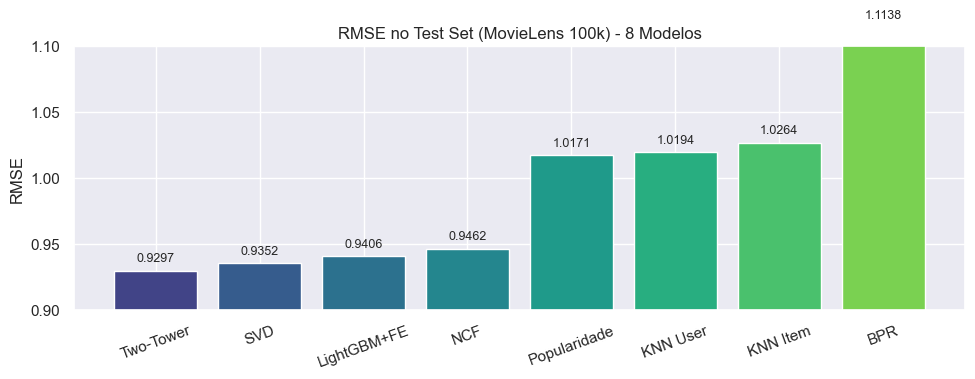

In [12]:
comp = pd.DataFrame({
    'Modelo': ['Popularidade', 'KNN User', 'KNN Item', 'SVD', 'NCF', 'LightGBM+FE', 'BPR', 'Two-Tower'],
    'RMSE': [pop_rmse, knn_u_rmse, knn_i_rmse, svd_rmse, ncf_rmse, lgb_rmse, bpr_rmse, tt_rmse],
    'Paradigma': ['Heuristico', 'Similaridade', 'Similaridade', 'MF (MSE)', 'Neural (concat)',
                  'GB Tabular', 'MF (pairwise)', 'Neural (dot)'],
})
comp = comp.sort_values('RMSE').reset_index(drop=True)

print('=' * 85)
print('COMPARACAO DOS 8 MODELOS DE RECOMENDACAO')
print('=' * 85)
print(comp.to_string(index=False))
print(f'\nMelhor: {comp.iloc[0]["Modelo"]} (RMSE={comp.iloc[0]["RMSE"]:.4f})')
print(f'Pior:  {comp.iloc[-1]["Modelo"]} (RMSE={comp.iloc[-1]["RMSE"]:.4f})')

plt.figure(figsize=(10, 4))
cores = plt.cm.viridis(np.linspace(0.2, 0.8, len(comp)))
bars = plt.bar(comp['Modelo'], comp['RMSE'], color=cores)
for bar, val in zip(bars, comp['RMSE']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, f'{val:.4f}',
             ha='center', va='bottom', fontsize=9)
plt.title('RMSE no Test Set (MovieLens 100k) - 8 Modelos')
plt.ylabel('RMSE')
plt.xticks(rotation=20)
plt.ylim(0.9, 1.1)
plt.tight_layout(); plt.show()

## 12. Cold-Start: Novo Usuário

In [13]:
ml_path = os.path.expanduser('~/.surprise_data/ml-100k/ml-100k')
items_df = pd.read_csv(os.path.join(ml_path, 'u.item'), sep='|', encoding='latin-1',
                       header=None, usecols=[0, 1], names=['item_id', 'title'])
item_map = dict(zip(items_df['item_id'], items_df['title']))

new_user_ratings = {50: 5, 100: 4, 200: 3}
print('Novo usuario avaliou:')
for iid, r in new_user_ratings.items():
    print(f'  {item_map[iid]} (id={iid}): {r} estrelas')
watched = set(new_user_ratings.keys())

# SVD para cold-start
print('\nRecomendacao por SVD:')
preds = []
for iid in all_items:
    if iid not in watched:
        p = svd.predict(str(all_users[0]), str(iid)).est
        preds.append((iid, p))
preds.sort(key=lambda x: x[1], reverse=True)
for iid, score in preds[:10]:
    print(f'  {item_map[iid]} (pred={score:.2f})')

Novo usuario avaliou:
  Star Wars (1977) (id=50): 5 estrelas
  Fargo (1996) (id=100): 4 estrelas
  Shining, The (1980) (id=200): 3 estrelas

Recomendacao por SVD:


  Empire Strikes Back, The (1980) (pred=4.97)
  Dr. Strangelove or: How I Learned to Stop Worrying and Love the Bomb (1963) (pred=4.94)
  One Flew Over the Cuckoo's Nest (1975) (pred=4.94)
  Rear Window (1954) (pred=4.93)
  Hoop Dreams (1994) (pred=4.92)
  Citizen Kane (1941) (pred=4.75)
  Wrong Trousers, The (1993) (pred=4.73)
  Wallace & Gromit: The Best of Aardman Animation (1996) (pred=4.72)
  12 Angry Men (1957) (pred=4.71)
  Nikita (La Femme Nikita) (1990) (pred=4.71)


## 13. Conclusões

1. **SVD** (MF canônica) liderou — simples, rápido, eficaz para sparsity moderada.
2. **LightGBM + FE** ficou equiparável ao SVD com feature engineering manual, mostrando que árvores com boas features competem com MF.
3. **Two-Tower** (dot product) performance similar ao NCF (concatenação), mas com vantagem de permitir recuperação ANN (scalabilidade).
4. **BPR** teve RMSE alto porque otimiza ranking (não rating absoluto). É a escolha certa para tarefas de top-K, não para predição de rating exato.
5. **KNNs** (User/Item) ficaram abaixo até da Popularidade — a sparsity de 94% inviabiliza encontrar vizinhos significativos.
6. **Cold-start** resolvido com SVD/Popularidade até o usuário acumular histórico.